# 第六讲：回归分析与机器学习回归模型

本 Notebook 使用一份销量预测数据，整理线性回归、正则化回归、KNN、SVR、回归树、随机森林和 GBDT 等方法。

回归建模的重点不只是把模型跑出来，还要说明模型假设、误差指标、预测效果和变量解释。不同模型适合回答的问题不同：线性模型更便于解释，树模型和集成模型更适合处理非线性关系。

## 1. 示例问题：根据经营数据预测销量

我们构造一个接近数学建模场景的示例数据集：目标变量是“销量”，解释变量包括广告投入、价格指数、访问量、促销强度、季节指数、竞品强度、口碑评分。

这个数据集故意包含非线性关系与变量交互，例如广告投入存在边际递减，促销会放大广告效果。因此，普通线性回归不一定足够。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import curve_fit

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
font_candidates = ['Microsoft YaHei', 'SimHei', 'SimSun', 'KaiTi', 'Arial Unicode MS']
selected_font = next((font for font in font_candidates if font in available_fonts), None)
if selected_font:
    plt.rcParams['font.sans-serif'] = [selected_font]
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = Path('第六讲示例数据.csv')
OUT_DIR = Path('第六讲_outputs')
OUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df.head()

,广告投入,价格指数,访问量,促销强度,季节指数,竞品强度,口碑评分,销量
0,13.17,95.15,16.01,2,1.00,0.75,3.92,96.67
1,59.47,112.25,7.94,1,0.95,0.14,3.66,146.60
2,45.02,102.41,16.58,2,0.85,0.70,3.30,121.83
3,66.91,76.69,16.05,2,1.00,0.27,3.94,186.53
4,67.78,93.91,5.68,0,1.00,0.85,4.24,75.82


In [ ]:
df.describe().round(2) #保留两位小数

,广告投入,价格指数,访问量,促销强度,季节指数,竞品强度,口碑评分,销量
count,220.00,220.00,220.00,220.00,220.00,220.00,220.00,220.00
mean,45.61,100.56,9.65,1.55,1.02,0.50,3.96,123.73
std,21.01,14.57,4.71,1.15,0.11,0.30,0.57,41.72
min,8.05,75.37,2.05,0.00,0.85,0.01,3.00,20.00
25%,28.18,89.05,5.65,0.00,0.95,0.23,3.46,91.58
50%,44.96,100.68,9.49,2.00,1.00,0.50,3.99,126.34
75%,64.01,112.37,13.81,3.00,1.10,0.75,4.51,153.17
max,84.64,124.87,18.00,3.00,1.20,1.00,4.87,234.94


## 2. 先看散点图：为什么线性模型可能不够？

建模前先画图。若散点大致沿直线分布，一元或多元线性模型可能就够；若趋势明显弯曲，就需要考虑多项式、SVR、树模型或集成模型。

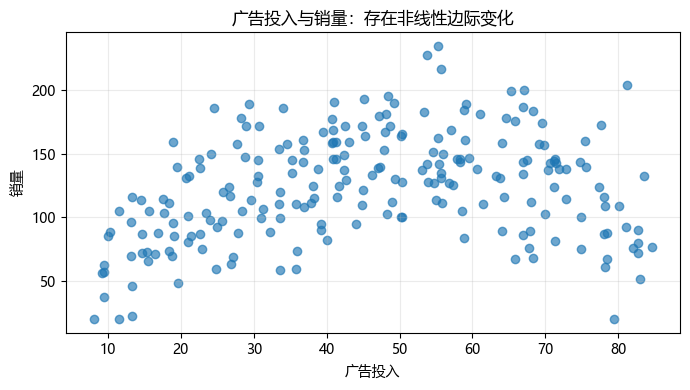

In [ ]:
plt.figure(figsize=(7,4))
plt.scatter(df['广告投入'], df['销量'], alpha=0.65) #绘制散点图
plt.xlabel('广告投入')
plt.ylabel('销量')
plt.title('广告投入与销量：存在非线性边际变化')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR/'01_广告投入与销量散点.png', dpi=180)
plt.show()

## 3. 训练集与测试集

为了判断模型是否真的有预测能力，需要把数据分成训练集和测试集。训练集用于估计模型参数，测试集用于模拟新数据预测。

In [4]:
features = ['广告投入','价格指数','访问量','促销强度','季节指数','竞品强度','口碑评分']
X = df[features]
y = df['销量']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train.shape, X_test.shape

((165, 7), (55, 7))

## 4. 基准模型：多元线性回归

多元线性回归假设目标变量可以表示为多个解释变量的线性组合：

$$
y=\beta_0+\beta_1x_1+\beta_2x_2+\cdots+\beta_px_p+\varepsilon
$$

它的优点是解释性强；缺点是难以刻画复杂非线性关系。

In [5]:
def metrics_table(name, model, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        '模型': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred),
        '预测值': pred,
        '模型对象': model
    }

baseline = metrics_table('多元线性回归', Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]))
baseline_display = {k:v for k,v in baseline.items() if k not in ['预测值','模型对象']}
baseline_display

{'模型': '多元线性回归',
 'MAE': 19.166184981738745,
 'RMSE': 23.289380274687353,
 'R2': 0.7422632015597626}

## 5. 正则化回归：Ridge 与 Lasso

### 5.1 为什么要正则化？

当解释变量之间相关性较强，或者变量数量较多时，普通线性回归的系数可能不稳定。正则化的思想是在原来的误差最小化目标中加入“惩罚项”，限制系数过大。

Ridge 回归目标函数：

$$
\min_{\beta}\sum_{i=1}^{n}(y_i-\hat y_i)^2+\lambda\sum_{j=1}^{p}\beta_j^2
$$

Lasso 回归目标函数：

$$
\min_{\beta}\sum_{i=1}^{n}(y_i-\hat y_i)^2+\lambda\sum_{j=1}^{p}|\beta_j|
$$

Ridge 使用 L2 惩罚，让系数变小但通常不为 0；Lasso 使用 L1 惩罚，可能把部分系数压成 0，因此有特征选择作用。

In [6]:
ridge_model = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=10.0))])
lasso_model = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.12, max_iter=10000))])

ridge_res = metrics_table('岭回归 Ridge', ridge_model)
lasso_res = metrics_table('Lasso 回归', lasso_model)

coef_df = pd.DataFrame({
    '变量': features,
    'Ridge系数': ridge_res['模型对象'].named_steps['model'].coef_,
    'Lasso系数': lasso_res['模型对象'].named_steps['model'].coef_
})
coef_df.round(4)

,变量,Ridge系数,Lasso系数
0,广告投入,12.0672,12.8210
1,价格指数,-14.4104,-15.2797
2,访问量,9.3331,9.9894
3,促销强度,24.6685,26.1694
4,季节指数,5.2135,5.5337
5,竞品强度,-8.5119,-9.0423
6,口碑评分,8.3982,8.9504


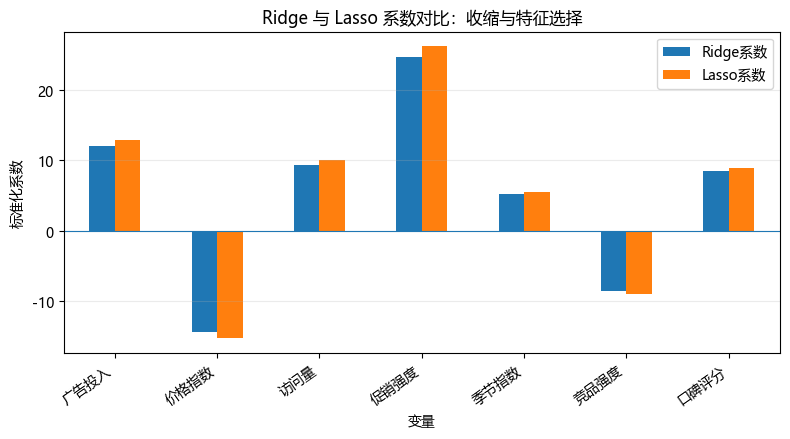

In [7]:
ax = coef_df.set_index('变量')[['Ridge系数','Lasso系数']].plot(kind='bar', figsize=(8,4.5))
plt.axhline(0, linewidth=0.8)
plt.title('Ridge 与 Lasso 系数对比：收缩与特征选择')
plt.ylabel('标准化系数')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR/'02_Ridge_Lasso系数对比.png', dpi=180)
plt.show()

## 6. 曲线拟合：用非线性函数描述趋势

当散点图呈现弯曲、递减、饱和或 S 型变化时，直线模型可能过于简单。曲线拟合的做法是先根据图像和现实机制选择函数形式，再估计参数，使拟合曲线尽量接近观测数据。

常见函数形式包括：

- 多项式模型：$\hat y=a_0+a_1x+a_2x^2+\cdots+a_mx^m$；
- 指数模型：$\hat y=ae^{bx}$；
- 对数模型：$\hat y=a+b\ln x$；
- Logistic 模型：$\hat y=\dfrac{L}{1+e^{-k(x-x_0)}}$。

其中 Logistic 模型中的 $L$ 表示上限，$k$ 表示增长速度，$x_0$ 表示拐点位置。曲线拟合不能只看 $R^2$，还要结合误差指标、残差图和现实含义判断。

### 6.1 选择一个变量观察曲线关系

这里先用 `广告投入` 解释 `销量`。这不是说销量只由广告决定，而是为了把“曲线拟合”的函数形式讲清楚。后面统一模型比较时，仍会把多变量模型放在同一个测试集上比较。

In [8]:
curve_x = '广告投入'
curve_y = '销量'

x_train_curve = X_train[curve_x].to_numpy(dtype=float)
x_test_curve = X_test[curve_x].to_numpy(dtype=float)
y_train_curve = y_train.to_numpy(dtype=float)
y_test_curve = y_test.to_numpy(dtype=float)

x_grid = np.linspace(df[curve_x].min(), df[curve_x].max(), 200)

### 6.2 先定义误差函数和 Logistic 函数

每一种曲线都会在测试集上计算 MAE、RMSE 和 $R^2$。Logistic 曲线写作：

$$
\hat y=\frac{L}{1+e^{-k(x-x_0)}}
$$

其中 $L$ 表示上限，$k$ 表示增长速度，$x_0$ 表示拐点位置。

In [9]:
def curve_metric(name, pred, model_object):
    return {
        '模型': name,
        'MAE': mean_absolute_error(y_test_curve, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test_curve, pred)),
        'R2': r2_score(y_test_curve, pred),
        '预测值': pred,
        '模型对象': model_object
    }


def logistic_func(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))


curve_predictors = {}
curve_model_results = []

### 6.3 多项式拟合

多项式模型通过加入 $x^2,x^3$ 等项表达弯曲趋势。阶数越高，拟合能力越强，但过高阶数容易把噪声也学进去。

In [10]:
for degree in [1, 2, 3]:
    coef = np.polyfit(x_train_curve, y_train_curve, degree)
    curve_predictors[f'{degree}阶多项式'] = lambda x, coef=coef: np.polyval(coef, x)
    curve_model_results.append(curve_metric(
        f'曲线拟合-{degree}阶多项式',
        np.polyval(coef, x_test_curve),
        {'type': 'polynomial', 'degree': degree, 'coef': coef}
    ))

pd.DataFrame([
    {k: v for k, v in item.items() if k not in ['预测值', '模型对象']}
    for item in curve_model_results
]).round(4)

,模型,MAE,RMSE,R2
0,曲线拟合-1阶多项式,35.1394,44.8517,0.0441
1,曲线拟合-2阶多项式,27.2904,35.3983,0.4046
2,曲线拟合-3阶多项式,26.9332,35.5075,0.4009


### 6.4 对数模型与指数模型

对数模型适合“前期增长快、后期增长放缓”的关系；指数模型适合近似按比例增长或衰减的过程。实际使用时要看散点图和测试误差，不能只凭模型名称选择。

In [11]:
log_model = LinearRegression()
log_model.fit(np.log(x_train_curve).reshape(-1, 1), y_train_curve)
curve_predictors['对数模型'] = lambda x: log_model.predict(np.log(x).reshape(-1, 1))
curve_model_results.append(curve_metric(
    '曲线拟合-对数模型',
    curve_predictors['对数模型'](x_test_curve),
    log_model
))

exp_model = LinearRegression()
exp_model.fit(x_train_curve.reshape(-1, 1), np.log(y_train_curve))
curve_predictors['指数模型'] = lambda x: np.exp(exp_model.predict(np.asarray(x).reshape(-1, 1)))
curve_model_results.append(curve_metric(
    '曲线拟合-指数模型',
    curve_predictors['指数模型'](x_test_curve),
    exp_model
))

### 6.5 Logistic 曲线

Logistic 模型适合 S 型增长或有上限的过程。当前广告投入与销量数据不一定严格呈 S 型，这里保留它，是为了让学生看到：模型形式要和现实机制匹配，不能为了“高级”而使用。

In [12]:
logistic_params, _ = curve_fit(
    logistic_func,
    x_train_curve,
    y_train_curve,
    p0=[y_train_curve.max() * 1.1, 0.05, np.median(x_train_curve)],
    bounds=([y_train_curve.max(), 0, x_train_curve.min()],
            [y_train_curve.max() * 3, 2, x_train_curve.max()]),
    maxfev=20000
)

curve_predictors['Logistic模型'] = lambda x: logistic_func(np.asarray(x), *logistic_params)
curve_model_results.append(curve_metric(
    '曲线拟合-Logistic模型',
    curve_predictors['Logistic模型'](x_test_curve),
    {'type': 'logistic', 'L': logistic_params[0], 'k': logistic_params[1], 'x0': logistic_params[2]}
))

pd.DataFrame({
    '参数': ['L 上限', 'k 增长速度', 'x0 拐点'],
    '估计值': logistic_params
}).round(4)

,参数,估计值
0,L 上限,216.6900
1,k 增长速度,0.0104
2,x0 拐点,18.0388


### 6.6 汇总曲线模型误差

所有曲线模型都使用同一训练集和测试集评价。这样比较才公平，也便于和后面的 KNN、SVR、树模型放在一起讨论。

In [13]:
curve_metrics = pd.DataFrame([
    {k: v for k, v in item.items() if k not in ['预测值', '模型对象']}
    for item in curve_model_results
])
curve_metrics[['MAE', 'RMSE', 'R2']] = curve_metrics[['MAE', 'RMSE', 'R2']].round(4)
curve_metrics.sort_values('RMSE')

,模型,MAE,RMSE,R2
1,曲线拟合-2阶多项式,27.2904,35.3983,0.4046
2,曲线拟合-3阶多项式,26.9332,35.5075,0.4009
3,曲线拟合-对数模型,33.1036,42.5358,0.1403
5,曲线拟合-Logistic模型,34.9966,44.7511,0.0484
0,曲线拟合-1阶多项式,35.1394,44.8517,0.0441
4,曲线拟合-指数模型,36.4882,46.2731,-0.0175


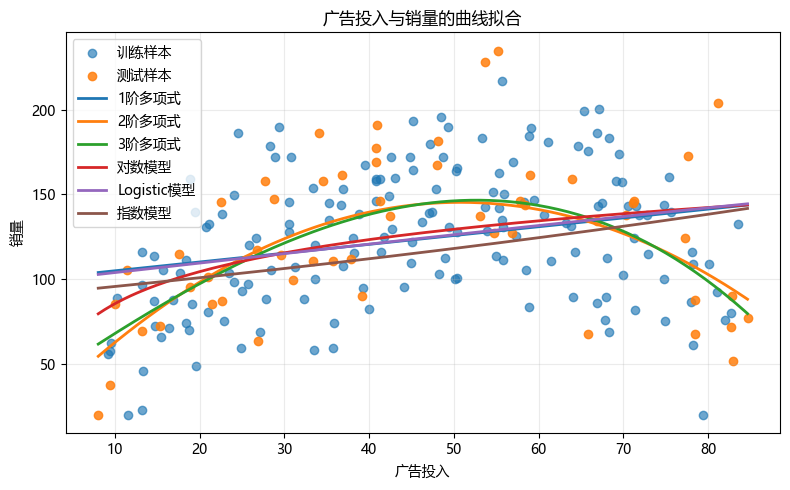

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(x_train_curve, y_train_curve, alpha=0.65, label='训练样本')
plt.scatter(x_test_curve, y_test_curve, alpha=0.85, label='测试样本')

plot_order = ['1阶多项式', '2阶多项式', '3阶多项式', '对数模型', 'Logistic模型', '指数模型']
for name in plot_order:
    plt.plot(x_grid, curve_predictors[name](x_grid), linewidth=2, label=name)

plt.xlabel(curve_x)
plt.ylabel(curve_y)
plt.title('广告投入与销量的曲线拟合')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / '03_曲线拟合候选模型.png', dpi=180)
plt.show()

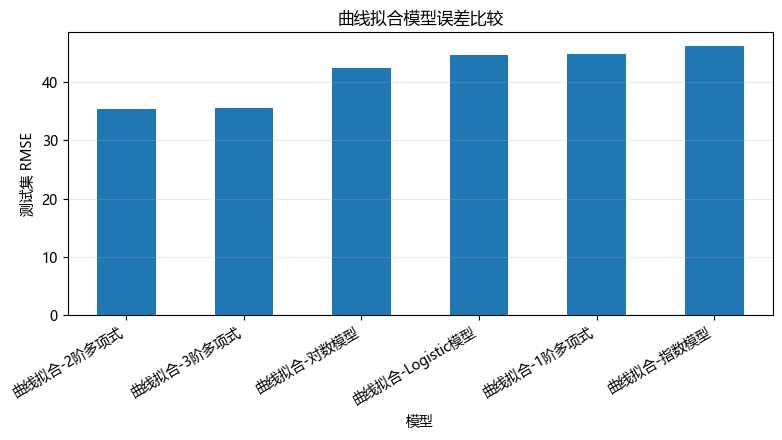

In [15]:
ax = curve_metrics.sort_values('RMSE').plot(
    x='模型',
    y='RMSE',
    kind='bar',
    figsize=(8, 4.5),
    legend=False
)
plt.ylabel('测试集 RMSE')
plt.title('曲线拟合模型误差比较')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / '04_曲线拟合误差比较.png', dpi=180)
plt.show()

从误差表和拟合图可以看到：曲线模型能够描述边际变化，但并不是阶数越高越好。若高阶多项式只是在训练区间内贴合得更紧，却缺少现实含义或测试误差没有下降，就不宜作为最终模型。

写作时建议同时给出函数形式、参数含义、测试集误差和残差图。对于 Logistic 曲线，还应说明上限 $L$、增长速度 $k$ 与拐点 $x_0$ 的现实解释。

## 7. KNN 回归：用相似样本的平均值预测

KNN 回归的核心思想：对一个新样本，先找到与它最相似的 K 个历史样本，再用这些邻居的目标值平均作为预测结果。

$$
\hat y(x)=\frac{1}{K}\sum_{i\in N_K(x)}y_i
$$

其中 `N_K(x)` 表示距离样本 `x` 最近的 K 个邻居。

K 太小，模型容易受噪声影响；K 太大，模型会过于平滑，局部特征被抹掉。

In [16]:
ks = range(1, 31)
knn_records = []
for k in ks:
    knn = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=k, weights='distance'))])
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    knn_records.append({'K': k, 'RMSE': np.sqrt(mean_squared_error(y_test, pred))})
knn_df = pd.DataFrame(knn_records)
knn_df.head()

,K,RMSE
0,1,32.936104
1,2,27.732612
2,3,27.800333
3,4,27.126726
4,5,27.290277


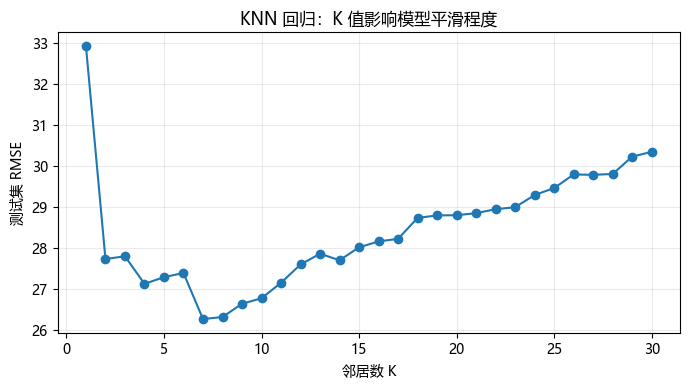

In [17]:
plt.figure(figsize=(7,4))
plt.plot(knn_df['K'], knn_df['RMSE'], marker='o')
plt.xlabel('邻居数 K')
plt.ylabel('测试集 RMSE')
plt.title('KNN 回归：K 值影响模型平滑程度')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR/'03_KNN_K值曲线.png', dpi=180)
plt.show()

## 8. SVR：支持向量回归

SVR 可以理解为“允许一定误差范围的回归模型”。它不是要求所有点都尽量贴合曲线，而是设置一个误差管道，只对超出管道的样本进行惩罚。

简化目标可以理解为：

$$
|y_i-\hat y_i|\leq \varepsilon
$$

若误差在 `\varepsilon` 范围内，就认为可以接受。通过核函数，SVR 可以处理非线性关系。常见 RBF 核：

$$
K(x_i,x_j)=\exp(-\gamma\|x_i-x_j\|^2)
$$

In [18]:
svr_res = metrics_table('SVR-RBF', Pipeline([('scaler', StandardScaler()), ('model', SVR(C=45, gamma='scale', epsilon=8))]))
{k:v for k,v in svr_res.items() if k not in ['预测值','模型对象']}

{'模型': 'SVR-RBF',
 'MAE': 17.81537328099254,
 'RMSE': 20.967267762770735,
 'R2': 0.7910972063336676}

## 9. 树模型回归：CART、随机森林、GBDT

树模型不直接假设线性关系，而是通过一系列“如果……那么……”的条件分裂，把样本空间划分成多个区域，每个区域给出一个预测值。

CART 回归树常用最小化平方误差来选择分裂：

$$
\min \left[\sum_{x_i\in R_1}(y_i-\bar y_{R_1})^2+\sum_{x_i\in R_2}(y_i-\bar y_{R_2})^2
\right]
$$

随机森林是多棵树并联平均，主要降低方差；GBDT 是多棵树串联纠错，后面的树重点拟合前面模型的残差。

In [19]:
tree_models = [
    ('CART 回归树', DecisionTreeRegressor(max_depth=4, random_state=42)),
    ('随机森林回归', RandomForestRegressor(n_estimators=160, max_depth=7, random_state=42)),
    ('GBDT 回归', GradientBoostingRegressor(n_estimators=180, learning_rate=0.05, max_depth=3, random_state=42)),
]
tree_results = [metrics_table(name, model) for name, model in tree_models]
pd.DataFrame([{k:v for k,v in r.items() if k not in ['预测值','模型对象']} for r in tree_results]).round(4)

,模型,MAE,RMSE,R2
0,CART 回归树,25.7311,30.1718,0.5674
1,随机森林回归,19.1972,22.5763,0.7578
2,GBDT 回归,16.7335,20.0968,0.8081


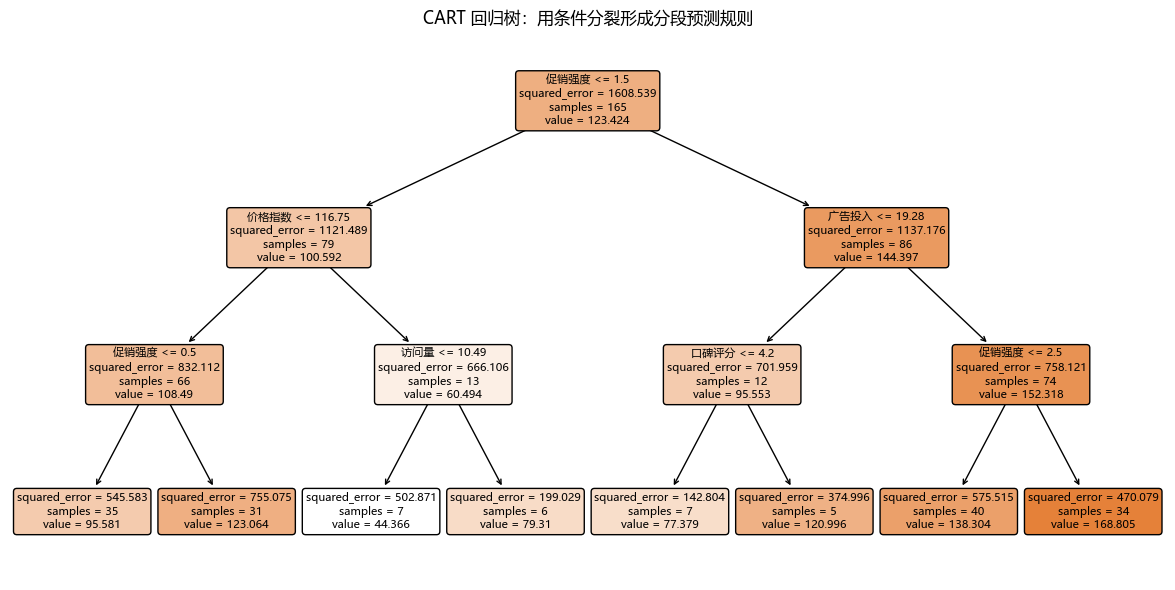

In [20]:
cart = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_train, y_train)
plt.figure(figsize=(12,6))
plot_tree(cart, feature_names=features, filled=True, rounded=True, fontsize=8)
plt.title('CART 回归树：用条件分裂形成分段预测规则')
plt.tight_layout()
plt.savefig(OUT_DIR/'04_CART回归树结构.png', dpi=180)
plt.show()

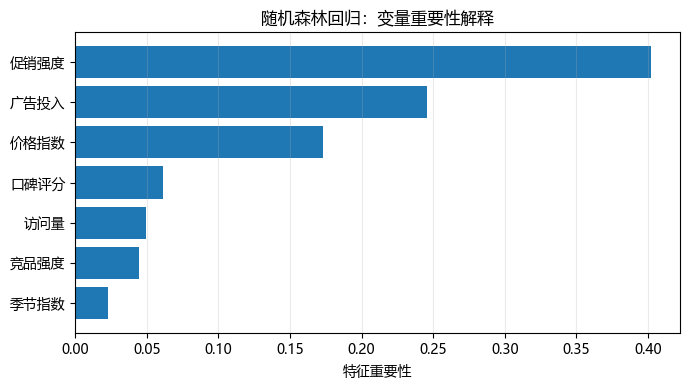

,变量,重要性
3,促销强度,0.4023
0,广告投入,0.2457
1,价格指数,0.1732
6,口碑评分,0.0616
2,访问量,0.0498
5,竞品强度,0.0449
4,季节指数,0.0226


In [21]:
rf = tree_results[1]['模型对象']
fi = pd.DataFrame({'变量':features, '重要性':rf.feature_importances_}).sort_values('重要性')
plt.figure(figsize=(7,4))
plt.barh(fi['变量'], fi['重要性'])
plt.xlabel('特征重要性')
plt.title('随机森林回归：变量重要性解释')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR/'05_随机森林特征重要性.png', dpi=180)
plt.show()
fi.sort_values('重要性', ascending=False).round(4)

## 10. 多模型统一比较

同一问题中可以比较多个模型，但必须使用相同训练集、相同测试集和相同误差指标。不要只看训练集拟合效果。

In [22]:
all_results = [baseline, ridge_res, lasso_res]
all_results.extend(curve_model_results)
all_results.append(metrics_table('多变量二次多项式回归', Pipeline([('poly', PolynomialFeatures(degree=2, include_bias=False)), ('scaler', StandardScaler()), ('model', Ridge(alpha=8.0))])))
all_results.append(metrics_table('KNN 回归', Pipeline([('scaler', StandardScaler()), ('model', KNeighborsRegressor(n_neighbors=7, weights='distance'))])))
all_results.append(svr_res)
all_results.extend(tree_results)
metrics = pd.DataFrame([{k:v for k,v in r.items() if k not in ['预测值','模型对象']} for r in all_results])
metrics[['MAE','RMSE','R2']] = metrics[['MAE','RMSE','R2']].round(4)
metrics.sort_values('RMSE')

,模型,MAE,RMSE,R2
9,多变量二次多项式回归,15.7940,18.3105,0.8407
14,GBDT 回归,16.7335,20.0968,0.8081
11,SVR-RBF,17.8154,20.9673,0.7911
13,随机森林回归,19.1972,22.5763,0.7578
0,多元线性回归,19.1662,23.2894,0.7423
2,Lasso 回归,19.2710,23.3527,0.7409
1,岭回归 Ridge,19.7484,23.6777,0.7336
10,KNN 回归,22.3345,26.2663,0.6722
12,CART 回归树,25.7311,30.1718,0.5674
4,曲线拟合-2阶多项式,27.2904,35.3983,0.4046


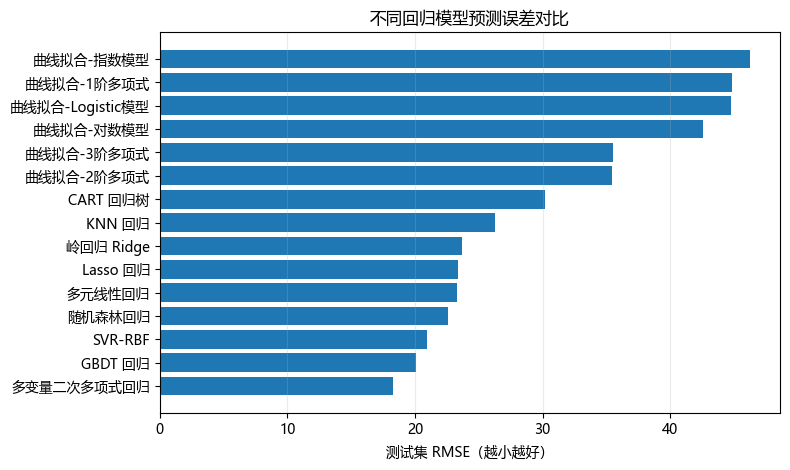

In [23]:
metrics_plot = metrics.sort_values('RMSE')
plt.figure(figsize=(8,4.8))
plt.barh(metrics_plot['模型'], metrics_plot['RMSE'])
plt.xlabel('测试集 RMSE（越小越好）')
plt.title('不同回归模型预测误差对比')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR/'06_模型RMSE对比.png', dpi=180)
plt.show()

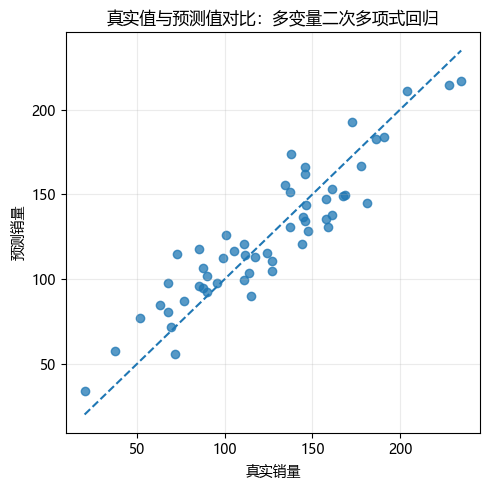

In [24]:
best_name = metrics.sort_values('RMSE').iloc[0]['模型']
best = [r for r in all_results if r['模型'] == best_name][0]
plt.figure(figsize=(5,5))
plt.scatter(y_test, best['预测值'], alpha=0.75)
minv = min(y_test.min(), best['预测值'].min())
maxv = max(y_test.max(), best['预测值'].max())
plt.plot([minv, maxv], [minv, maxv], linestyle='--')
plt.xlabel('真实销量')
plt.ylabel('预测销量')
plt.title(f'真实值与预测值对比：{best_name}')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR/'07_最佳模型真实预测对比.png', dpi=180)
plt.show()

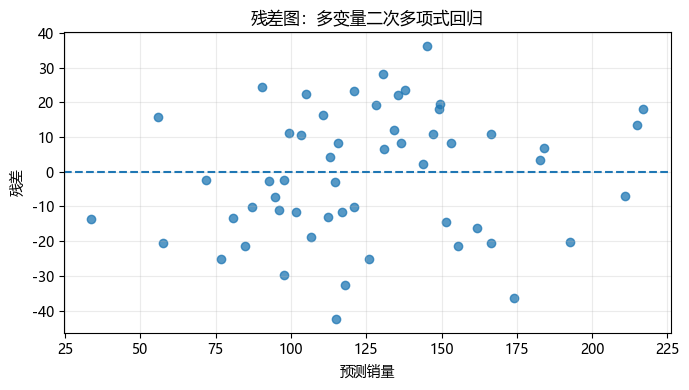

In [25]:
resid = y_test - best['预测值']
plt.figure(figsize=(7,4))
plt.scatter(best['预测值'], resid, alpha=0.75)
plt.axhline(0, linestyle='--')
plt.xlabel('预测销量')
plt.ylabel('残差')
plt.title(f'残差图：{best_name}')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR/'08_最佳模型残差图.png', dpi=180)
plt.show()

## 11. 论文写法示例

可以这样写：

> 为比较不同回归模型在销量预测任务中的表现，本文在相同训练集和测试集下分别建立多元线性回归、岭回归、Lasso 回归、KNN 回归、SVR、CART 回归树、随机森林和 GBDT 模型，并采用 MAE、RMSE 和 R² 作为评价指标。结果显示，集成树模型在测试集上的 RMSE 较低，说明其能够较好刻画广告投入、价格、促销强度等变量与销量之间的非线性关系。进一步通过特征重要性分析发现，广告投入、访问量和口碑评分对销量预测贡献较大。

注意：论文中不是模型越多越好，而是要解释为什么最终选择某一个模型。

In [26]:
metrics.to_csv(OUT_DIR/'Notebook_模型评价指标.csv', index=False, encoding='utf-8-sig')
pred_out = X_test.copy()
pred_out['真实销量'] = y_test
for r in all_results:
    pred_out[r['模型']] = np.round(r['预测值'], 2)
pred_out.to_csv(OUT_DIR/'Notebook_测试集预测结果.csv', index=False, encoding='utf-8-sig')
print('已保存结果到:', OUT_DIR)

已保存结果到: 第六讲_outputs


## 课后小作业：比较可解释模型与非线性模型

请基于本讲已经得到的 `metrics` 和 `all_results` 完成下面任务：

1. 找出测试集 RMSE 最低的模型；
2. 比较多元线性回归、岭回归、随机森林和 GBDT 的 MAE、RMSE、$R^2$；
3. 计算最优模型的残差均值和残差标准差；
4. 用一段话说明：如果论文既要解释变量影响，又要提高预测精度，应如何选择模型。

In [27]:
# 小作业解答
focus_models = ['多元线性回归', '岭回归 Ridge', '随机森林回归', 'GBDT 回归']

homework6 = metrics[metrics['模型'].isin(focus_models)].copy()
homework6 = homework6.sort_values('RMSE').reset_index(drop=True)
display(homework6)

best_model_name = metrics.sort_values('RMSE').iloc[0]['模型']
best_result = [item for item in all_results if item['模型'] == best_model_name][0]
residual = y_test - best_result['预测值']

print(f'测试集 RMSE 最低的模型：{best_model_name}')
print(f'最优模型残差均值：{residual.mean():.3f}')
print(f'最优模型残差标准差：{residual.std():.3f}')

linear_rmse = metrics.loc[metrics['模型'] == '多元线性回归', 'RMSE'].iloc[0]
best_rmse = metrics['RMSE'].min()
improve_rate = (linear_rmse - best_rmse) / linear_rmse * 100

print(f'相对多元线性回归，最优模型 RMSE 下降约 {improve_rate:.2f}%。')
print('结论：若论文强调解释变量影响，可优先报告线性或正则化回归；若任务更重视预测精度，可选择测试集误差更低的非线性模型，并用特征重要性或残差图补充解释。')

,模型,MAE,RMSE,R2
0,GBDT 回归,16.7335,20.0968,0.8081
1,随机森林回归,19.1972,22.5763,0.7578
2,多元线性回归,19.1662,23.2894,0.7423
3,岭回归 Ridge,19.7484,23.6777,0.7336


测试集 RMSE 最低的模型：多变量二次多项式回归
最优模型残差均值：-1.089
最优模型残差标准差：18.447
相对多元线性回归，最优模型 RMSE 下降约 21.38%。
结论：若论文强调解释变量影响，可优先报告线性或正则化回归；若任务更重视预测精度，可选择测试集误差更低的非线性模型，并用特征重要性或残差图补充解释。
